<div align="center">

# 🧠 **CBS5502 — Computational Linguistics and NLP Technologies**

### 🐍 **Python Tutorial**
### 📅 *March 11, 2026*

---

## 🏷️ **Meaning Representation Techniques**
## 🔁 **Embeddings and Semantic Relation**

---

### 👨‍🏫 **Instructor**  
**Dr. WAN Mingyu**

### 👨‍🏫 **Teaching Assistant**  
**Mr. BAO Xiaoyi**

</div>

## 🎯 Learning Objectives

By the end of this session, you will be able to:

- ✅ Explain the **distributional hypothesis**
- ✅ Understand how **word embeddings** represent meaning
- ✅ Compute **cosine similarity** between words
- ✅ Explore semantic relations such as:
  - synonymy
  - analogy
  - semantic clustering
- ✅ Interpret embedding results critically

---

## 🔎 Key Concept

> “You shall know a word by the company it keeps.”  
> — J. R. Firth

Word embeddings are based on this idea:  
Words that appear in similar contexts tend to have similar meanings.

We will see how this idea becomes a **mathematical model of meaning**.

---

## 🛠 What You Need
- Install required libraries
- Load pre-trained word embeddings
- Perform similarity calculations
- Visualize semantic relationships
- Complete guided exercises

Each section includes **examples**, **exercises**, and **solutions** to ensure hands-on learning. Let's get started! 🚀

In [1]:
# Install required libraries
!pip -q install gensim scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.3 MB/s eta 0:00:00


In [3]:
# Import core libraries
import numpy as np
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

---

## 🔎 1. Model loading:

### `glove-wiki-gigaword-100`

---

📚 **Trained on:**  
- Wikipedia  
- Gigaword corpus  

🔢 **Vector dimension:**  
- 100-dimensional word vectors  

🧠 **How it learns meaning:**  
- From large-scale word co-occurrence patterns  

---

This model already contains **pre-trained representations for hundreds of thousands of words**,  
ready for semantic similarity, analogy, and clustering tasks.

---

In [4]:
# Load a small pre-trained embedding model
model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(model.key_to_index))

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000


In [5]:
# Get vector representation of a word
vector_king = model["king"]

print("Vector dimension:", len(vector_king))
print("First 10 values:", vector_king[:10])

Vector dimension: 100
First 10 values: [-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ]


---

## 📐 2. Cosine Similarity and Semantic Meaning

## 🔎 Why Do We Need a Similarity Measure?

In word embeddings, each word is represented as a vector:

$$
\vec{w} \in \mathbb{R}^n
$$

If meaning is encoded numerically, we need a way to measure:

> **How close are two word vectors in semantic space?**

This is where **cosine similarity** comes in.

---

## 📏 What Is Cosine Similarity?

Cosine similarity measures the **angle between two vectors**.

For two word vectors \( \vec{A} \) and \( \vec{B} \):

$$
\text{cosine}(\vec{A}, \vec{B}) =
\frac{\vec{A} \cdot \vec{B}}
{\|\vec{A}\| \|\vec{B}\|}
$$

---

## 📊 Value Range

- **1** → Vectors point in the same direction (very similar meaning)
- **0** → Vectors are orthogonal (unrelated meaning)
- **-1** → Opposite directions (rare in word embeddings)

---

## 🧠 Why Use Cosine Similarity for Meaning?

### ✅ 1. Direction Matters More Than Magnitude

In semantic space:
- The **direction** of a vector encodes meaning.
- The **length** (magnitude) may vary due to word frequency.

Cosine similarity ignores magnitude and focuses only on direction.

---

### ✅ 2. Robust to Frequency Effects

High-frequency words may have larger vector norms.  
Cosine normalization prevents frequent words from dominating similarity scores.

---

### ✅ 3. Geometric Interpretation of Meaning

If two words appear in similar contexts:

$$
\vec{doctor} \approx \vec{nurse}
$$

Their vectors will point in similar directions → small angle → high cosine similarity.

---

## 🔍 Example Interpretation

If:

$$
\text{cosine}(\vec{car}, \vec{automobile}) \approx 0.85
$$

This suggests strong semantic similarity.

If:

$$
\text{cosine}(\vec{car}, \vec{banana}) \approx 0.05
$$

This suggests little semantic relation.

---

## 🎯 Key Insight

Cosine similarity operationalizes the **distributional hypothesis**:

> Words that occur in similar contexts  
> → Have similar vector directions  
> → Have high cosine similarity  

Thus, semantic similarity becomes a **geometric property** of vector space.

---

In [6]:
#the function of cs
def cosine_sim(word1, word2):
    vec1 = model[word1]
    vec2 = model[word2]
    similarity = cosine_similarity([vec1], [vec2])[0][0]
    return similarity

In [7]:
# Test meaning pairs with cosine similarity
pairs = [
    ("car", "automobile"),
    ("dog", "cat"),
    ("car", "banana"),
    ("doctor", "nurse"),
]

scores = []
for w1, w2 in pairs:
    s = cosine_sim(w1, w2)
    scores.append((w1, w2, s))
    print(f"{w1} - {w2}: {s:.4f}")

print("\nInterpretation:")
print("- Higher score => words appear in more similar contexts.")
print("- car/automobile is expected to be very high (near-synonym).")
print("- car/banana is usually low due to semantic mismatch.")
print("- Similarity reflects usage-context, not strict dictionary synonymy.")

car - automobile: 0.6832
dog - cat: 0.8798
car - banana: 0.1486
doctor - nurse: 0.7522


In [15]:
sim_words = model.most_similar("happy", topn=10)
print(sim_words)

print("\nWhy results may look poor:")
print("1) Static embeddings ignore sentence context and polysemy.")
print("2) General corpora contain noisy/non-lexical usage patterns.")
print("3) Domain mismatch between your expectation and training corpus.")
print("\nHow to improve:")
print("- Filter noisy tokens and normalize text.")
print("- Use larger/domain-specific corpora.")
print("- Use contextual encoders (e.g., BERT-style models).")

[("'m", 0.8413287997245789),
 ('feel', 0.8132575750350952),
 ("'re", 0.8048083186149597),
 ('i', 0.7938276529312134),
 ("'ll", 0.7916273474693298),
 ('really', 0.7903971076011658),
 ('glad', 0.7833361029624939),
 ('good', 0.7821646332740784),
 ('we', 0.7808917164802551),
 ('sure', 0.7788466215133667)]

---

## 👑 Word Analogy with Vector Arithmetic
---

## 🔎 What Is Happening Here?

This function performs **vector arithmetic in embedding space**.

Mathematically, the model computes:

$$
\vec{v}
=
\vec{king}
-
\vec{man}
+
\vec{woman}
$$

Then it searches for the word whose vector is **closest to** \( \vec{v} \)  
using cosine similarity.

---

### Formally:

$$
w^*
=
\arg\max_{w \in V}
\cos\left(
\vec{w},
\vec{v}
\right)
$$

We run the following code:


In [10]:

model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

[('queen', 0.7698540687561035),
 ('monarch', 0.6843381524085999),
 ('throne', 0.6755736470222473),
 ('daughter', 0.6594556570053101),
 ('princess', 0.6520534157752991)]

---

# 📊 Semantic Clustering with Word Embeddings

In this section, we group words into clusters based on their vector representations.

---

## 🔎 What Is Happening Here?

### 1️⃣ Selecting Words

We manually choose words from different semantic categories:

- 👑 **Royalty / Gender**
  - king
  - queen
  - man
  - woman

- 🍎 **Fruits**
  - apple
  - banana
  - orange

- 🐺 **Animals**
  - dog
  - cat
  - wolf

---

In [16]:
words = ["king", "queen", "man", "woman",
         "apple", "banana", "orange",
         "dog", "cat", "wolf"]

# Extract vectors
vectors = np.array([model[w] for w in words])

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(vectors)

# Display clusters
for word, label in zip(words, labels):
    print(f"{word}: Cluster {label}")

king: Cluster 2
queen: Cluster 2
man: Cluster 0
woman: Cluster 0
apple: Cluster 1
banana: Cluster 1
orange: Cluster 1
dog: Cluster 1
cat: Cluster 1
wolf: Cluster 1


---

# 📉 Visualizing Word Embeddings with PCA

In this section, we reduce high-dimensional word vectors to 2 dimensions
so that we can visualize them.
---

## 🔎 What Is Happening Here?

### 1️⃣ Dimensionality Reduction

Each word embedding originally lives in:

$$
\mathbb{R}^{100}
$$

We cannot directly visualize 100-dimensional space.

So we apply **Principal Component Analysis (PCA)**  
to project the vectors into:

$$
\mathbb{R}^{2}
$$

This allows us to visualize the embeddings in a 2D plot.

---

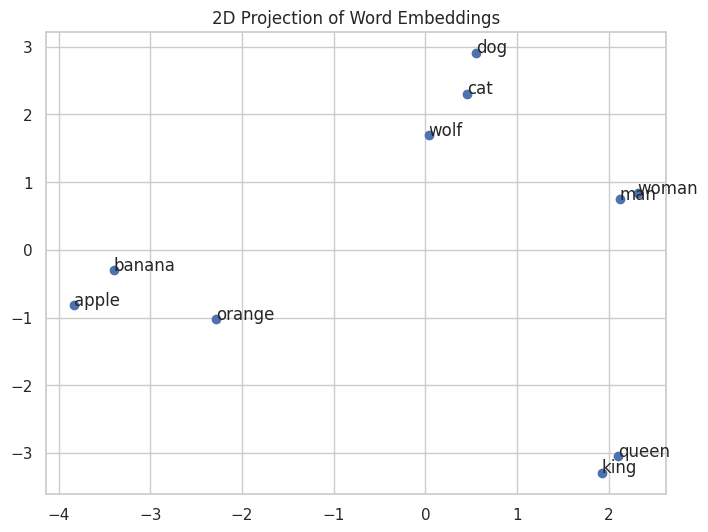

In [12]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced[i,0], reduced[i,1]))

plt.title("2D Projection of Word Embeddings")
plt.show()

---

# 🏦 Using Cosine Similarity to Explore Ambiguity

---

## 🧠 Why Is "Bank" Interesting?

The word **"bank"** is **polysemous** (it has multiple meanings):

- 🏦 **Financial institution**
- 🌊 **River bank**

However, in a **static embedding model** like GloVe:

There is only **one vector representation**:

$$
\vec{bank}
$$

Both meanings are merged into a single representation.

---

Consider the following code:

In [13]:
model.most_similar("bank")

[('banks', 0.8057132959365845),
 ('banking', 0.7530707120895386),
 ('credit', 0.7037603259086609),
 ('investment', 0.6939943432807922),
 ('financial', 0.6777413487434387),
 ('securities', 0.668834388256073),
 ('lending', 0.664503276348114),
 ('funds', 0.6484885811805725),
 ('ubs', 0.6483405232429504),
 ('finance', 0.6462422609329224)]

---

## 📊 What Do the Results Show?

The output may include words like:

- loan  
- credit  
- river  
- money  
- shore  

### This tells us:

- The model captures multiple senses  
- But it does not separate them  
- The dominant sense depends on training frequency  

---

## ⚠️ Limitation of Cosine Similarity for Ambiguity

Cosine similarity measures closeness to:

$$
\vec{bank}
$$

But since there is only **one vector representation**:

- Financial and river meanings are blended  
- Ambiguity is not explicitly resolved  

This is a limitation of **static embeddings**.

---

## ✅ How Can Ambiguity Be Better Resolved?

To handle ambiguity properly, we need:

- **Contextual embeddings** (e.g., BERT)  
- Context-specific representations  

In contextual models:

$$
\vec{bank}_{\text{financial}}
\neq
\vec{bank}_{\text{river}}
$$

The word vector depends on the **sentence context**,  
so different meanings receive different representations.

---


---

# ✅ 📌 Summary

## 🧠 What You Learned Today

By the end of this tutorial, you should now understand that:

✔ **Meaning can be represented numerically**  
> Words can be encoded as vectors in a high-dimensional space.

✔ **Word embeddings implement the distributional hypothesis**  
> Words that appear in similar contexts tend to have similar meanings.

✔ **Cosine similarity measures semantic closeness**  
> The angle between vectors reflects semantic similarity.

✔ **Analogies emerge from vector arithmetic**  
> Semantic relationships can be modeled through operations like:  
> \[
> \textbf{king} - \textbf{man} + \textbf{woman} \approx \textbf{queen}
> \]

✔ **Clustering reveals semantic structure**  
> Similar words naturally group together in vector space.

✔ **Embeddings contain bias and limitations**  
> Models learn patterns from data — including ambiguity and social bias.

---


# 🎯 🧪 Exercises for Students

Submit *yourname_cs*.ipynb to BB by **March 15** as the active participation for Week 8.

## 1️⃣ Compare Similarity Scores

Use cosine similarity to compare:

- `strong` / `powerful`
- `strong` / `coffee`
- `strong` / `weak`

🔎 **Questions to consider:**
- Which pair is most similar?
- Why might “strong coffee” behave differently?
- Does distributional similarity always equal synonymy?

---

## 2️⃣ Try an Analogy Task

Compute:

$$
\vec{v} =
\vec{walking}
-
\vec{walk}
+
\vec{swim}
$$

🤔 What linguistic relation is being captured here?
- Morphology?
- Verb tense?
- Semantic pattern?

---

## 3️⃣ Design Your Own Word Cluster Experiment

Choose 8–12 words from:
- animals
- professions
- emotions
- food
- countries

Then:
- Extract their embeddings  
- Apply clustering (e.g., KMeans)  
- Visualize using PCA  

📊 **Discussion prompts:**
- Do similar categories cluster together?
- Are there surprising groupings?
- What might explain unexpected patterns?

---

# 🚀 Challenge Question (Optional)

Can you find:
- A case where similarity is high but meanings differ?
- A case where similarity is low but words are related?

What does this tell us about distributional models of meaning?

---

In [ ]:
# ===== Exercise Solutions =====

# 1) Compare requested similarity scores
pairs_ex1 = [("strong", "powerful"), ("strong", "coffee"), ("strong", "weak")]
print("Exercise 1: cosine similarity")
for a, b in pairs_ex1:
    print(f"{a:>8} / {b:<8} -> {cosine_sim(a, b):.4f}")
print("Likely: strong-powerful highest; strong-coffee may still be moderate due to collocation.")


# 2) Analogy task: walking - walk + swim
vec = model["walking"] - model["walk"] + model["swim"]
print("\nExercise 2: analogy result")
for word, score in model.similar_by_vector(vec, topn=5):
    print(f"{word:<12} {score:.4f}")
print("This usually captures morphology/tense-like transformation patterns.")


# 3) Word cluster experiment
cluster_words = [
    "dog", "cat", "wolf", "lion",
    "doctor", "nurse", "teacher", "engineer",
    "happy", "sad", "angry", "calm"
]
cluster_vecs = np.array([model[w] for w in cluster_words])
km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_ids = km.fit_predict(cluster_vecs)

print("\nExercise 3: cluster assignment")
for w, cid in zip(cluster_words, cluster_ids):
    print(f"{w:<10} -> cluster {cid}")

# Optional quick 2D visualization
pca2 = PCA(n_components=2)
xy = pca2.fit_transform(cluster_vecs)
plt.figure(figsize=(9, 6))
for i, w in enumerate(cluster_words):
    plt.scatter(xy[i, 0], xy[i, 1], c=f"C{cluster_ids[i]}")
    plt.text(xy[i, 0] + 0.02, xy[i, 1] + 0.02, w, fontsize=9)
plt.title("Exercise 3: PCA view of custom word clusters")
plt.show()